# 400-Day Churn — Order-Level Panel (CatBoost)

Every **customer-order** (purchase-day) is one row. The model is a discrete-time repeat-purchase
hazard classifier: given a customer's state *as of* an order, will they order again within 400 days?

**How the model scores itself (evaluation).** Per **row**: it predicts `churn_prob` for each
customer-order and compares it to that row's `churned_400d` label on **held-out customers**
(AUC / PR-AUC). Because one customer contributes many correlated rows, the train/test split is
**grouped by `shopify_customer_id`** — no customer appears in both train and test.

**How it scores a customer (deployment).** Score the customer's **current / latest** order row →
`churn_prob` (and `p_repeat = 1 − churn_prob`) → risk tier. That's their live churn score.

**Projected orders (PLTV bridge).** From a row's `p_repeat` we can project expected additional
orders geometrically (`p/(1−p)`). We validate the per-stage hazard with a **calibration-by-order_seq**
check (does predicted repeat rate match actual at each order number?), which is exactly what the
projection relies on.

**Visuals:** ROC, top feature importances, churn-score distribution — plus the customer-level
calibration + projected-orders view.

## 1. Install dependencies

In [1]:
!pip install catboost gdown -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


## 2. Configuration

In [2]:
DRIVE_CSV_URL = "https://drive.google.com/file/d/1huFYkAtEPCd7eI_DcbN2D6Tx0FUuqxE2/view?usp=sharing"

LABEL_COL      = "churned_400d"
GROUP_COL      = "shopify_customer_id"     # grouping key for the split
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
TOP_N_FEATURES = 25
CHURN_WINDOW   = 400                       # days (for labelling context only)

CB_PARAMS = dict(
    iterations=1000, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
    eval_metric="AUC", random_seed=RANDOM_STATE, verbose=False,
)

## 3. Load the feature CSV from Drive

In [3]:
import re, gdown
import pandas as pd
import numpy as np

def load_drive_csv(url, out="orders_panel.csv"):
    m = re.search(r"/d/([A-Za-z0-9_-]+)", url) or re.search(r"[?&]id=([A-Za-z0-9_-]+)", url)
    if not m: raise ValueError("Could not find a file id in DRIVE_CSV_URL.")
    gdown.download(id=m.group(1), output=out, quiet=False)
    return out

df = pd.read_csv(load_drive_csv(DRIVE_CSV_URL)).dropna(how="all").dropna(axis=1, how="all")
assert LABEL_COL in df.columns and GROUP_COL in df.columns, f"Columns: {list(df.columns)}"
print(f"Loaded {df.shape[0]:,} order-rows across {df[GROUP_COL].nunique():,} customers x {df.shape[1]} cols")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1huFYkAtEPCd7eI_DcbN2D6Tx0FUuqxE2
To: /content/orders_panel.csv
100%|██████████| 48.7M/48.7M [00:00<00:00, 116MB/s]


Loaded 200,000 order-rows across 111,826 customers x 40 cols


,shopify_customer_id,split_rand,order_date,order_seq,next_order_date,days_to_next_order,churned_400d,days_since_first_order,days_since_prev_order,avg_gap_so_far,...,this_order_style,this_order_channel,this_order_store,order_month,entry_department,first_product_style,acq_channel,acq_store,customer_state,state_missing
0,1783403459,0.15607,2025-05-09,1,2025-05-24,15.0,0,0,NaN,NaN,...,Soco Patch Five-Panel Trucker,Retail,001 - South Congress Austin,5,Accessories,Soco Patch Five-Panel Trucker,Retail,001 - South Congress Austin,TX,False
1,1783403459,0.15607,2025-05-24,2,NaN,NaN,1,15,15.0,15.0,...,The Earl,Retail,037 - International Plaza Tampa,5,Accessories,Soco Patch Five-Panel Trucker,Retail,001 - South Congress Austin,TX,False
2,2002381571,0.94718,2025-03-14,1,NaN,NaN,1,0,NaN,NaN,...,The Nolan II,eComm,Online,3,Men's Footwear,The Nolan II,eComm,Online,TX,False
3,2197471683,0.31356,2023-01-08,1,2023-09-02,237.0,0,0,NaN,NaN,...,The Jake,Retail,014 - Fifth and Broadway Nashville,1,Men's Footwear,The Jake,Retail,014 - Fifth and Broadway Nashville,TN,False
4,2197471683,0.31356,2023-09-02,2,2023-11-23,82.0,0,237,237.0,237.0,...,The Nolan,eComm,Online,9,Men's Footwear,The Jake,Retail,014 - Fifth and Broadway Nashville,TN,False


## 4. Quick look

In [4]:
print("Rows (customer-orders):", f"{len(df):,}")
print("Unique customers:", f"{df[GROUP_COL].nunique():,}")
print("Avg rows / customer:", round(len(df)/df[GROUP_COL].nunique(), 2))
print("\nLabel distribution (churned_400d):")
print(df[LABEL_COL].value_counts(dropna=False))
print(f"Row-level churn base rate: {df[LABEL_COL].mean():.3f}")
print("\nChurn rate by order_seq (should fall as order number rises):")
print(df.groupby("order_seq")[LABEL_COL].agg(["size","mean"]).head(10))

Rows (customer-orders): 200,000
Unique customers: 111,826
Avg rows / customer: 1.79

Label distribution (churned_400d):
churned_400d
1    115578
0     84422
Name: count, dtype: int64
Row-level churn base rate: 0.578

Churn rate by order_seq (should fall as order number rises):
             size      mean
order_seq                  
1          111826  0.680164
2           41063  0.566617
3           18509  0.469934
4            9523  0.393048
5            5386  0.321760
6            3225  0.267907
7            2119  0.211420
8            1450  0.188966
9            1026  0.134503
10            770  0.110390


## 5. Preprocess

Drop ids / label-side columns; keep `order_seq` and all cumulative features (legitimate state).
Booleans → 0/1; categorical NaNs → "missing"; numeric NaNs left for CatBoost.

In [5]:
# reference / id columns (NOT features). GROUP_COL kept out of X but used for the split.
ID_COLS = ["shopify_customer_id", "split_rand", "order_date", "next_order_date"]
# label-side numeric (describes the outcome) — must not be a feature
LEAKAGE_COLS = ["days_to_next_order"]

CAT_COLS = ["this_order_department", "this_order_style", "this_order_channel",
            "this_order_store", "order_month", "entry_department",
            "first_product_style", "acq_channel", "acq_store", "customer_state"]

DROP_COLS = ID_COLS + LEAKAGE_COLS + [LABEL_COL]

def prepare_features(frame):
    f = frame.drop(columns=[c for c in DROP_COLS if c in frame.columns])
    for c in f.columns:                       # boolean flags -> 0/1
        if f[c].dtype == bool:
            f[c] = f[c].astype(int)
    for c in [c for c in CAT_COLS if c in f.columns]:
        f[c] = np.where(f[c].isna(), "missing", f[c].astype(str))
    return f

data = df.dropna(subset=[LABEL_COL]).copy()
y = data[LABEL_COL].astype(int)
X = prepare_features(data)
groups = data[GROUP_COL].values               # customer id per row, aligned to X
cat_features = [c for c in CAT_COLS if c in X.columns]

print(f"{X.shape[0]:,} rows x {X.shape[1]} features")
print("order_seq kept as feature:", "order_seq" in X.columns)
print("categoricals:", cat_features)

200,000 rows x 34 features
order_seq kept as feature: True
categoricals: ['this_order_department', 'this_order_style', 'this_order_channel', 'this_order_store', 'order_month', 'entry_department', 'first_product_style', 'acq_channel', 'acq_store', 'customer_state']


## 6. Grouped train / test split + train

`GroupShuffleSplit` keeps every customer's rows entirely on one side of the split — no
`shopify_customer_id` in both train and test. A second grouped split carves a validation set
out of train for early stopping. Assertions confirm the customer sets are disjoint.

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from catboost import CatBoostClassifier

# ---- test split (grouped by customer) ----
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
y_train, y_test = y.iloc[tr_idx], y.iloc[te_idx]
g_train         = groups[tr_idx]

# ---- validation split out of train (also grouped) ----
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
fit_idx, val_idx = next(gss2.split(X_train, y_train, g_train))
X_fit, X_val = X_train.iloc[fit_idx], X_train.iloc[val_idx]
y_fit, y_val = y_train.iloc[fit_idx], y_train.iloc[val_idx]

# ---- no customer leaks across splits ----
assert set(groups[te_idx]).isdisjoint(set(g_train)),               "customer in train AND test!"
assert set(g_train[val_idx]).isdisjoint(set(g_train[fit_idx])),    "customer in fit AND val!"
print(f"customers -> fit {len(set(g_train[fit_idx])):,} | val {len(set(g_train[val_idx])):,} | test {len(set(groups[te_idx])):,}  (disjoint ✓)")

model = CatBoostClassifier(cat_features=cat_features, **CB_PARAMS)
model.fit(X_fit, y_fit, eval_set=(X_val, y_val), use_best_model=True)

probs  = model.predict_proba(X_test)[:, 1]     # per-ROW churn probability
auc    = roc_auc_score(y_test, probs)
pr_auc = average_precision_score(y_test, probs)
print(f"\nTest AUC {auc:.3f}  PR-AUC {pr_auc:.3f}  |  {len(y_test):,} order-rows, churn rate {y_test.mean():.3f}")

customers -> fit 71,568 | val 17,892 | test 22,366  (disjoint ✓)

Test AUC 0.729  PR-AUC 0.774  |  40,149 order-rows, churn rate 0.577


## 7. Visualize (ROC · feature importance · churn-score distribution)

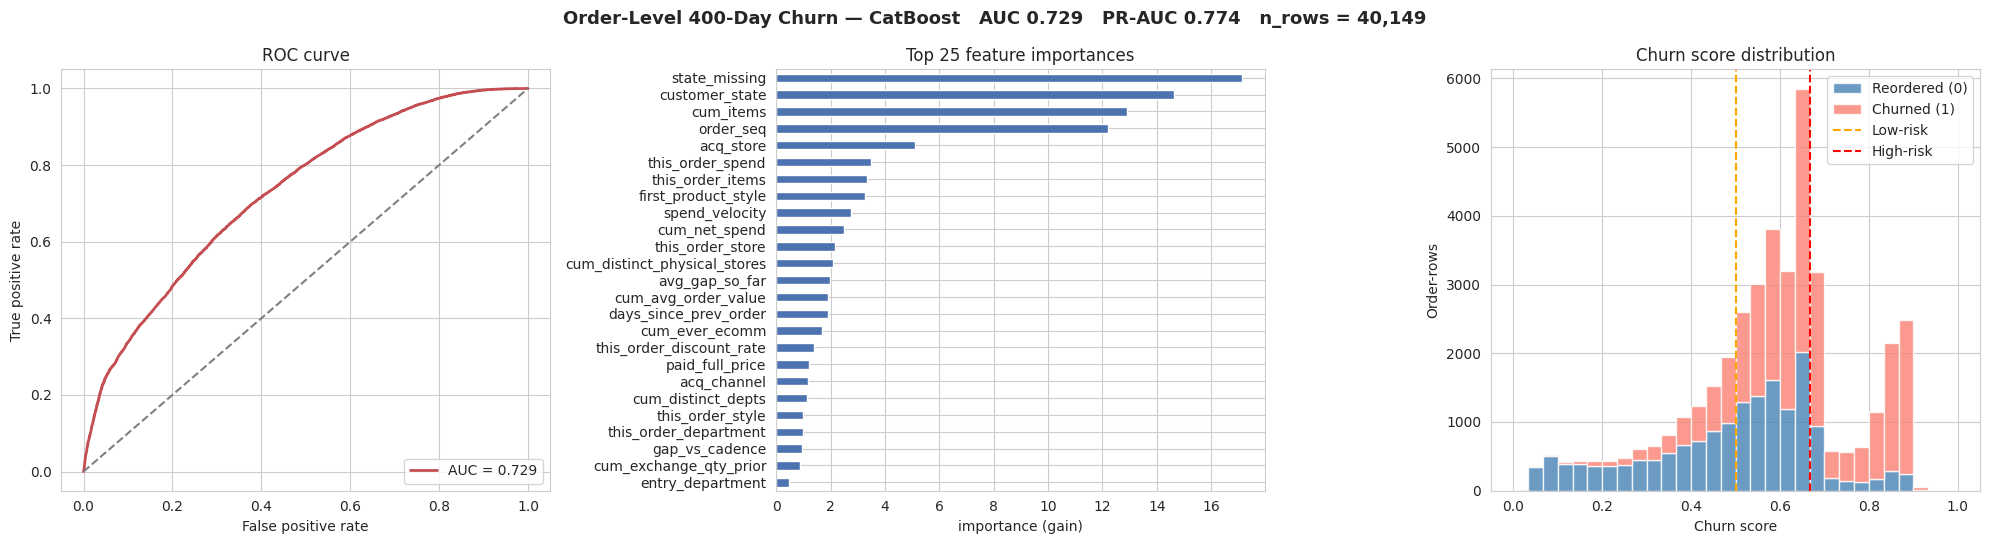

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def visualize(model, X_test, y_test, probs, top_n=TOP_N_FEATURES):
    yt = np.asarray(y_test)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
    fig.suptitle(f"Order-Level 400-Day Churn — CatBoost   AUC {auc:.3f}   PR-AUC {pr_auc:.3f}   "
                 f"n_rows = {len(yt):,}", fontsize=13, weight="bold")

    fpr, tpr, _ = roc_curve(yt, probs)
    axes[0].plot(fpr, tpr, color="#C44E52", lw=2, label=f"AUC = {auc:.3f}")
    axes[0].plot([0,1],[0,1],"--",color="gray")
    axes[0].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
    axes[0].legend(loc="lower right")

    imp = (pd.Series(model.feature_importances_, index=X_test.columns)
             .sort_values(ascending=False).head(top_n).sort_values())
    imp.plot(kind="barh", ax=axes[1], color="#4C72B0")
    axes[1].set(title=f"Top {top_n} feature importances", xlabel="importance (gain)")

    bins = np.linspace(0, 1, 31)
    not_ch, ch = probs[yt==0], probs[yt==1]
    axes[2].hist(not_ch, bins=bins, label="Reordered (0)", color="steelblue", alpha=0.8)
    axes[2].hist(ch, bins=bins, label="Churned (1)", color="salmon", alpha=0.8,
                 bottom=np.histogram(not_ch, bins=bins)[0])
    axes[2].axvline(0.5,  color="orange", ls="--", lw=1.5,
                    label="Low-risk")
    axes[2].axvline(0.667, color="red",    ls="--", lw=1.5,
                    label="High-risk")
    axes[2].set(title="Churn score distribution", xlabel="Churn score", ylabel="Order-rows")
    axes[2].legend()
    plt.tight_layout(); plt.show()

visualize(model, X_test, y_test, probs)

## 8. Customer-level check — calibration by order_seq + projected orders

**Why this matters.** The per-row AUC tells you the model ranks *orders*. But the business acts on
*customers*, and the PLTV projection chains each order's `p_repeat` into expected future orders. Two
customer-level views:

1. **Calibration by `order_seq`** — at each order number, does the model's mean predicted repeat
   probability match the actual repeat rate? If the lines track, the per-stage hazard is trustworthy
   and the geometric projection is sound.
2. **Projected additional orders** — for each test customer, take their **latest** order's `p_repeat`
   and project `p/(1−p)` expected future orders (the Phase-2 CLV bridge). We histogram it.

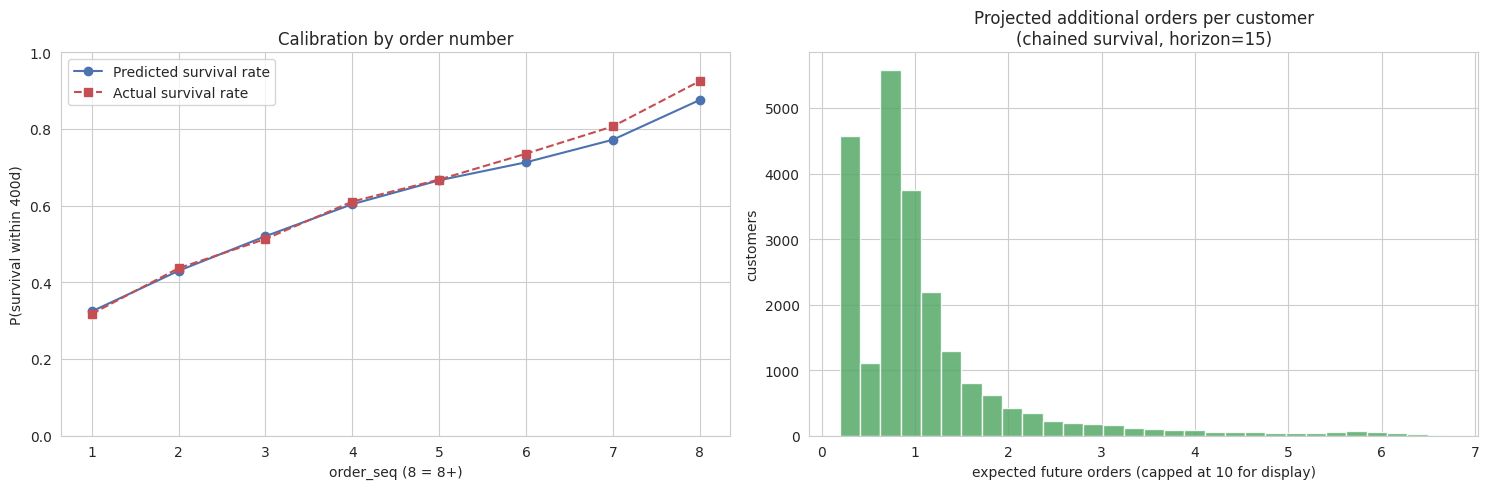

Calibration by order_seq:
 seq_bucket     n pred_repeat actual_repeat
          1 22366       0.324         0.317
          2  8161       0.430         0.436
          3  3722       0.520         0.513
          4  1878       0.603         0.610
          5  1071       0.666         0.668
          6   623       0.713         0.735
          7   413       0.772         0.806
          8  1915       0.875         0.924

Projected ADDITIONAL orders by current order_seq (should rise with loyalty):
order_seq
1      0.65
2      1.16
3      1.81
4      2.56
5      3.38
6      4.20
7      5.05
8      5.29
9      5.41
10     5.77
11     5.76
12     5.74
13     5.82
14     6.17
15     6.04
16     6.10
17     6.07
18     6.18
19     6.22
20     6.32
21     5.98
22     6.15
23     6.35
24     6.29
25     6.26
26     6.24
29     6.29
31     5.96
32     6.42
33     6.02
38     6.34
39     6.51
40     6.53
50     6.55
55     6.30
59     6.48
67     6.47
69     6.39
90     6.39
100    6.54

Median pr

In [9]:
# ============================================================================
# Customer-level: calibration by order_seq + CHAINED-SURVIVAL projected orders
#                 (+ a VERY rough projected $ value using a flat population AOV)
# ============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MAX_BUCKET  = 8       # order_seq >= 8 share one "8+" repeat rate (steady state)
HORIZON     = 15      # max future orders to chain (bounds the projection)
GENERAL_AOV = 310.23  # flat population-wide net AOV — PLACEHOLDER for Phase-2 Gamma-Gamma

# --- per-row scored frame on TEST customers ---
test_scored = pd.DataFrame({
    "shopify_customer_id": df.iloc[te_idx][GROUP_COL].values,
    "order_seq":  X_test["order_seq"].values,
    "churn_prob": probs,
    "churned":    y_test.values,
})
test_scored["p_repeat"]   = 1 - test_scored["churn_prob"]
test_scored["seq_bucket"] = np.where(test_scored["order_seq"] >= MAX_BUCKET, MAX_BUCKET,
                                     test_scored["order_seq"])

# --- calibration by order_seq (predicted vs actual repeat rate) ---
cal = (test_scored.groupby("seq_bucket")
       .agg(n=("churned", "size"),
            pred_repeat=("p_repeat", "mean"),
            actual_repeat=("churned", lambda s: 1 - s.mean()))
       .reset_index())

# --- population forward hazard curve r_k (model-predicted repeat rate per order number) ---
r_by_seq = test_scored.groupby("seq_bucket")["p_repeat"].mean()
r_arr = np.array([r_by_seq.loc[i] for i in range(1, MAX_BUCKET + 1)])   # r_arr[k-1] = repeat rate at order k
def r_of(seqs):
    return r_arr[np.minimum(np.asarray(seqs), MAX_BUCKET).astype(int) - 1]

# --- chained-survival projection from each customer's LATEST order ---
latest = test_scored.sort_values("order_seq").groupby("shopify_customer_id").tail(1).copy()
k        = latest["order_seq"].to_numpy()
survival = latest["p_repeat"].to_numpy(dtype=float).copy()   # step 1: their own next-order probability
expected_add = survival.copy()
for step in range(1, HORIZON):                               # steps 2..HORIZON: population curve
    survival     = survival * r_of(k + step)
    expected_add = expected_add + survival
latest["proj_additional_orders"] = expected_add
latest["proj_total_orders"]      = latest["order_seq"] + expected_add
latest["proj_additional_value"]  = latest["proj_additional_orders"] * GENERAL_AOV   # rough $ estimate

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(cal["seq_bucket"], cal["pred_repeat"],   "o-",  color="#4C72B0", label="Predicted survival rate")
axes[0].plot(cal["seq_bucket"], cal["actual_repeat"], "s--", color="#C44E52", label="Actual survival rate")
axes[0].set(title="Calibration by order number", xlabel="order_seq (8 = 8+)",
            ylabel="P(survival within 400d)", ylim=(0, 1))
axes[0].legend()

axes[1].hist(latest["proj_additional_orders"].clip(upper=10), bins=30, color="#55A868", alpha=0.85)
axes[1].set(title=f"Projected additional orders per customer\n(chained survival, horizon={HORIZON})",
            xlabel="expected future orders (capped at 10 for display)", ylabel="customers")
plt.tight_layout(); plt.show()

# --- readouts ---
print("Calibration by order_seq:")
print(cal.to_string(index=False, formatters={"pred_repeat": "{:.3f}".format,
                                             "actual_repeat": "{:.3f}".format}))

print(f"\nProjected ADDITIONAL orders by current order_seq (should rise with loyalty):")
print(latest.groupby("order_seq")["proj_additional_orders"].mean().round(2).to_string())
print(f"\nMedian projected additional orders: {latest['proj_additional_orders'].median():.2f}")

print(f"\n--- VERY rough $ value (flat AOV = ${GENERAL_AOV:,.2f} net; placeholder for Gamma-Gamma) ---")
print(f"  Median projected additional lifetime value / customer: ${latest['proj_additional_value'].median():,.0f}")
print(f"  Mean   projected additional lifetime value / customer: ${latest['proj_additional_value'].mean():,.0f}")
print("  Projected additional $ by current order_seq:")
print((latest.groupby("order_seq")["proj_additional_value"].mean()
       .map(lambda v: f"${v:,.0f}")).to_string())

## Validation 1: AUC for each bucket (leakage check)

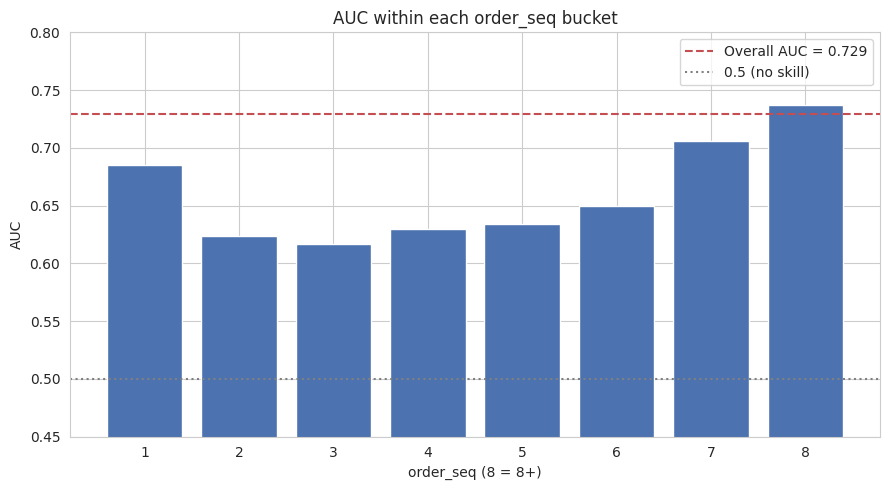

 order_seq     n churn_rate   auc
         1 22366      0.683 0.685
         2  8161      0.564 0.624
         3  3722      0.487 0.617
         4  1878      0.390 0.630
         5  1071      0.332 0.634
         6   623      0.265 0.649
         7   413      0.194 0.706
         8  1915      0.076 0.737

Overall AUC (all rows, cross-stage):      0.729
Sample-weighted mean WITHIN-bucket AUC:   0.665
=> ~0.065 of the overall AUC is order_seq separating stages,
   ~0.165 is genuine within-stage discrimination.


In [ ]:
MAX_BUCKET = 8
ev = pd.DataFrame({
    "order_seq":  X_test["order_seq"].values,
    "churn_prob": probs,
    "churned":    np.asarray(y_test),
})
ev["seq_bucket"] = np.where(ev["order_seq"] >= MAX_BUCKET, MAX_BUCKET, ev["order_seq"])

rows = []
for b, g in ev.groupby("seq_bucket"):
    n, pos = len(g), int(g["churned"].sum())
    auc_b = roc_auc_score(g["churned"], g["churn_prob"]) if 0 < pos < n else np.nan   # needs both classes
    rows.append({"order_seq": int(b), "n": n, "churn_rate": g["churned"].mean(), "auc": auc_b})
by_seq = pd.DataFrame(rows)

overall = roc_auc_score(ev["churned"], ev["churn_prob"])
valid   = by_seq.dropna(subset=["auc"])
w_auc   = np.average(valid["auc"], weights=valid["n"])      # sample-weighted within-bucket AUC

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(by_seq["order_seq"].astype(str), by_seq["auc"], color="#4C72B0")
ax.axhline(overall, color="#C44E52", ls="--", label=f"Overall AUC = {overall:.3f}")
ax.axhline(0.5, color="gray", ls=":", label="0.5 (no skill)")
ax.set(title="AUC within each order_seq bucket", xlabel="order_seq (8 = 8+)",
       ylabel="AUC", ylim=(0.45, max(0.8, overall + 0.05)))
ax.legend()
plt.tight_layout(); plt.show()

print(by_seq.to_string(index=False, formatters={
    "churn_rate": "{:.3f}".format,
    "auc": lambda v: "n/a" if pd.isna(v) else f"{v:.3f}"}))
print(f"\nOverall AUC (all rows, cross-stage):      {overall:.3f}")
print(f"Sample-weighted mean WITHIN-bucket AUC:   {w_auc:.3f}")
print(f"=> ~{overall - w_auc:.3f} of the overall AUC is order_seq separating stages,")
print(f"   ~{w_auc - 0.5:.3f} is genuine within-stage discrimination.")

## Validation 2: Score for 100 random customers with flat AOV for PLTV

In [ ]:
# ============================================================================
# Validation preview: 100 random customers — churn score of their LATEST order,
# current order stage, projected future orders (chained), and a VERY rough LTV.
# Uses `latest` from the projection cell. Flat AOV is a placeholder for the
# Phase-2 Gamma-Gamma per-customer AOV.
# ============================================================================
import numpy as np, pandas as pd
GENERAL_AOV = 310.23    # flat net AOV placeholder

sample = latest.sample(n=min(100, len(latest)), random_state=RANDOM_STATE).copy()
sample["last_order_churn_score"] = sample["churn_prob"]                         # churn prob at their last order
sample["orders_so_far"]          = sample["order_seq"]                          # = # purchase-days to date
sample["proj_future_orders"]     = sample["proj_additional_orders"]             # chained-survival projection
sample["pred_remaining_value"]   = sample["proj_future_orders"] * GENERAL_AOV   # future $ (orders yet to come)
sample["pred_total_ltv"]         = (sample["orders_so_far"] + sample["proj_future_orders"]) * GENERAL_AOV

view = (sample[["shopify_customer_id", "orders_so_far", "last_order_churn_score",
                "proj_future_orders", "pred_remaining_value", "pred_total_ltv"]]
        .sort_values("pred_total_ltv", ascending=False)
        .reset_index(drop=True))

pd.set_option("display.max_rows", 200)
print(view.to_string(index=False, formatters={
    "last_order_churn_score": "{:.3f}".format,
    "proj_future_orders":     "{:.2f}".format,
    "pred_remaining_value":   "${:,.0f}".format,
    "pred_total_ltv":         "${:,.0f}".format,
}))

print(f"\n--- {len(sample)} random customers | flat AOV = ${GENERAL_AOV:,.2f} (placeholder for Gamma-Gamma) ---")
print(f"Median churn score (last order): {sample['last_order_churn_score'].median():.3f}")
print(f"Median projected FUTURE orders : {sample['proj_future_orders'].median():.2f}")
print(f"Median predicted REMAINING value: ${sample['pred_remaining_value'].median():,.0f}")
print(f"Median predicted TOTAL LTV      : ${sample['pred_total_ltv'].median():,.0f}")

 shopify_customer_id  orders_so_far last_order_churn_score proj_future_orders pred_remaining_value pred_total_ltv
       6425703055555             23                  0.072               6.42               $1,992         $9,128
       6539906318531              5                  0.311               3.68               $1,141         $2,692
       6551310762179              5                  0.386               3.28               $1,017         $2,568
       2040200462445              4                  0.308               3.10                 $962         $2,203
       5426223939779              3                  0.394               2.21                 $686         $1,617
       6549212561603              3                  0.466               1.95                 $604         $1,535
       6509887520963              3                  0.633               1.34                 $416         $1,347
       6468802969795              2                  0.408               1.70           

## Validation 3: Projected future orders vs actual future orders for 2023-2024 customers

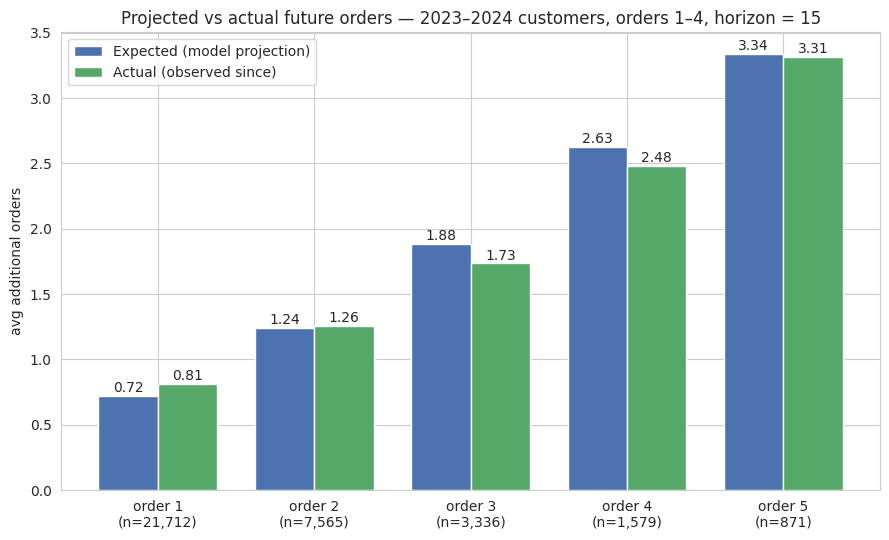

           customers  expected  actual
order_seq                             
1              21712      0.72    0.81
2               7565      1.24    1.26
3               3336      1.88    1.73
4               1579      2.63    2.48
5                871      3.34    3.31

Caveats: 'actual' counts only matured subsequent orders (very recent orders aren't counted yet), so it slightly UNDERcounts; 'expected' counts reorders that stay within a 400-day cadence. Restricting to 2023–2024 keeps that gap small. Uses out-of-sample test rows.


In [ ]:
# ============================================================================
# VALIDATION 3 — projected (expected) future orders vs ACTUAL future orders
#   Backtest on out-of-sample (TEST) customers whose 2nd–4th order fell in
#   2023–2024, so we've had time to watch what they actually did next.
#     expected = chained-survival projection at that order (p_self × tail Mₖ)
#     actual   = how many more (matured) orders that customer went on to make
# ============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MAX_BUCKET, HORIZON = 8, 15

# scored TEST rows (out-of-sample) with order_date attached
val = pd.DataFrame({
    "shopify_customer_id": df.iloc[te_idx][GROUP_COL].to_numpy(),
    "order_date": pd.to_datetime(df.iloc[te_idx]["order_date"].to_numpy()),
    "order_seq":  X_test["order_seq"].to_numpy(),
    "churn_prob": probs,
})
val["p_repeat"] = 1 - val["churn_prob"]

# ACTUAL future orders = (customer's highest matured order_seq) − this order_seq
val["actual_future_orders"] = (val.groupby("shopify_customer_id")["order_seq"].transform("max")
                               - val["order_seq"])

# EXPECTED future orders = p_self × tail multiplier Mₖ  (Mₖ = 1 + r_{k+1}·M_{k+1})
cap   = np.minimum(val["order_seq"], MAX_BUCKET)
r_arr = np.array([val.loc[cap == k, "p_repeat"].mean() for k in range(1, MAX_BUCKET + 1)])
r_arr = pd.Series(r_arr).ffill().bfill().to_numpy()          # fill any empty high stage
r_at  = lambda m: r_arr[min(m, MAX_BUCKET) - 1]
M = {HORIZON + 1: 1.0}
for k in range(HORIZON, 0, -1):
    M[k] = 1.0 + r_at(k + 1) * M[k + 1]
val["expected_future_orders"] = val["p_repeat"] * val["order_seq"].clip(upper=HORIZON).map(M)

# backtest slice: early orders (2023–2024), stages 2–4
bt = val[val["order_date"].dt.year.isin([2023, 2024]) & val["order_seq"].isin([1, 2, 3, 4, 5])]
summ = (bt.groupby("order_seq")
          .agg(customers=("expected_future_orders", "size"),
               expected=("expected_future_orders", "mean"),
               actual=("actual_future_orders", "mean")))

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(summ)); w = 0.38
ax.bar(x - w/2, summ["expected"], w, label="Expected (model projection)", color="#4C72B0")
ax.bar(x + w/2, summ["actual"],   w, label="Actual (observed since)",     color="#55A868")
for i,(e,a) in enumerate(zip(summ["expected"], summ["actual"])):
    ax.text(i - w/2, e + 0.03, f"{e:.2f}", ha="center", fontsize=10)
    ax.text(i + w/2, a + 0.03, f"{a:.2f}", ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"order {int(s)}\n(n={int(n):,})" for s, n in zip(summ.index, summ["customers"])])
ax.set(title=f"Projected vs actual future orders — 2023–2024 customers, orders 1–4, horizon = {HORIZON}",
       ylabel="avg additional orders")
ax.legend(); plt.tight_layout(); plt.show()

print(summ.round(2).to_string())
print("\nCaveats: 'actual' counts only matured subsequent orders (very recent orders aren't "
      "counted yet), so it slightly UNDERcounts; 'expected' counts reorders that stay within a "
      "400-day cadence. Restricting to 2023–2024 keeps that gap small. Uses out-of-sample test rows.")

## Comparison: cadence vs churn

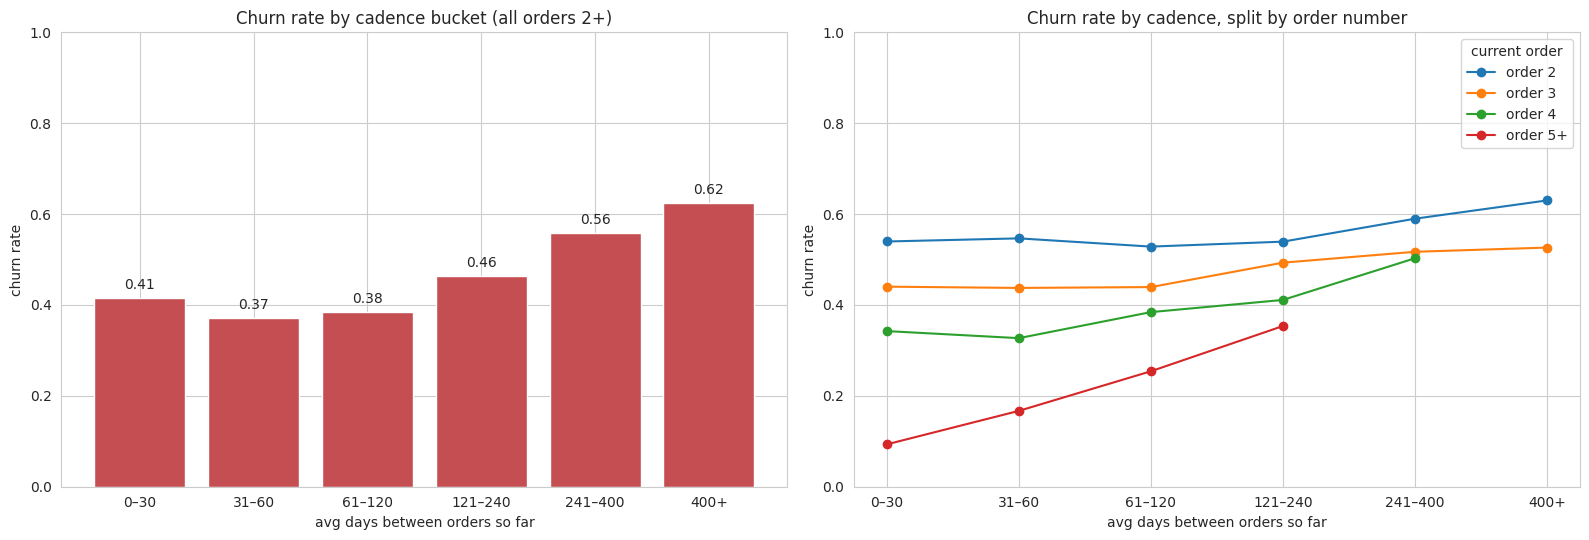

Overall churn rate by cadence bucket:
            churn_rate      n
gap_bucket                   
0–30             0.415  16595
31–60            0.371   5554
61–120           0.385   7111
121–240          0.464   7441
241–400          0.558   4552
400+             0.625   2874

Churn rate by cadence × order number:
seq_grp         2      3      4      5
gap_bucket                            
0–30        0.540  0.440  0.343  0.093
31–60       0.547  0.438  0.327  0.167
61–120      0.528  0.439  0.384  0.254
121–240     0.539  0.493  0.411  0.354
241–400     0.590  0.517  0.503    NaN
400+        0.630  0.526    NaN    NaN


In [ ]:
# ============================================================================
# VALIDATION 2 — does a longer purchase cadence mean higher churn risk?
#   Descriptive: REAL churn label vs avg_gap_so_far (avg days between a
#   customer's orders up to that point), overall and split by order number.
# ============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

g = df[df["order_seq"] >= 2].copy()                       # avg_gap_so_far defined from order 2 on
bins = [0, 30, 60, 120, 240, 400, 1e9]
labs = ["0–30", "31–60", "61–120", "121–240", "241–400", "400+"]
g["gap_bucket"] = pd.cut(g["avg_gap_so_far"], bins=bins, labels=labs)
g["seq_grp"]    = np.where(g["order_seq"] >= 5, 5, g["order_seq"])   # 5 = 5+

overall = g.groupby("gap_bucket", observed=True)["churned_400d"].agg(churn_rate="mean", n="size")
piv     = g.pivot_table(index="gap_bucket", columns="seq_grp",
                        values="churned_400d", aggfunc="mean", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].bar(overall.index.astype(str), overall["churn_rate"], color="#C44E52")
for i, v in enumerate(overall["churn_rate"]): axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
axes[0].set(title="Churn rate by cadence bucket (all orders 2+)",
            xlabel="avg days between orders so far", ylabel="churn rate", ylim=(0, 1))
for s in piv.columns:
    axes[1].plot(piv.index.astype(str), piv[s], marker="o", label=f"order {int(s)}{'+' if s == 5 else ''}")
axes[1].set(title="Churn rate by cadence, split by order number",
            xlabel="avg days between orders so far", ylabel="churn rate", ylim=(0, 1))
axes[1].legend(title="current order"); plt.tight_layout(); plt.show()

print("Overall churn rate by cadence bucket:")
print(overall.assign(churn_rate=lambda d: d["churn_rate"].round(3)).to_string())
print("\nChurn rate by cadence × order number:")
print(piv.round(3).to_string())

## 9. Export model artifact

In [ ]:
import sklearn, catboost, joblib
from google.colab import files
print("PIN:", "scikit-learn==" + sklearn.__version__, "catboost==" + catboost.__version__)

artifact = {
    "model": model,
    "feature_cols": list(X.columns),
    "cat_features": cat_features,
    "id_cols": ID_COLS, "leakage_cols": LEAKAGE_COLS,
    "label_col": LABEL_COL, "group_col": GROUP_COL, "churn_window_days": CHURN_WINDOW,
    "train_vocab": {c: sorted(set(map(str, X[c].unique()))) for c in cat_features},
    "model_version": "churn_order_level_v0.1",
}
joblib.dump(artifact, "churn_order_level_artifact.joblib")
files.download("churn_order_level_artifact.joblib")

## 10. Score customers (optional)

At deployment you score each customer's **latest** order row to get their current churn risk + tier,
then project expected future orders for CLV.

In [ ]:
# new = pd.read_csv(load_drive_csv("PASTE_NEW_URL", out="new_panel.csv"))
# Xn = prepare_features(new).reindex(columns=X.columns)
# new_scored = new[[GROUP_COL, "order_seq"]].copy()
# new_scored["churn_prob"] = model.predict_proba(Xn)[:, 1]
# # keep each customer's latest order = their current state
# cur = new_scored.sort_values("order_seq").groupby(GROUP_COL).tail(1).copy()
# cur["p_repeat"] = 1 - cur["churn_prob"]
# cur["risk_tier"] = np.where(cur["churn_prob"]>=0.7,"High",
#                     np.where(cur["churn_prob"]>=0.5,"Medium","Low"))
# pc = cur["p_repeat"].clip(upper=0.95)
# cur["proj_additional_orders"] = pc/(1-pc)
# cur.to_csv("customer_churn_scores.csv", index=False); cur.head()